# Smart TAR Assistant: ML Workflow and Analytics

## Purpose
This notebook demonstrates the machine learning workflow behind the Smart TAR Assistant.  
The goal is to classify Travel Authorization Request (TAR) cases into:

- **approve**
- **clarify**
- **hold**

using a combination of:
- structured review features
- engineered business-rule indicators
- text features derived from travel justifications

## Why this matters
Administrative travel review often involves repeated pattern-checking across flags, trip details, and justification text. This workflow shows how ML can support reviewers by surfacing likely outcomes, highlighting influential features, and generating analytics for a frontend dashboard.

## Scope note
This notebook uses **synthetic data** to prototype the modeling and analytics workflow. The results are useful for demonstrating the system design, but they should not be interpreted as real-world operational performance.

In [412]:
import json
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score, 
    recall_score, 
    f1_score, 
    accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.base import BaseEstimator, TransformerMixin

## 1. Synthetic Dataset Generation

This section creates a synthetic TAR review dataset with:
- trip metadata
- flag counts
- justification text
- a target review action

The labels are generated from rule-driven logic so the notebook can simulate a realistic review workflow while remaining fully reproducible.

## Load Synthetic Data

In [413]:
random.seed(42)
np.random.seed(42)

labels = ["approve", "clarify", "hold"]

destination_profiles = {
    "San Diego": {
        "trip_min": 2, "trip_max": 6, "packet_bias": 0.78,
        "common_type": "training"
    },
    "San Jose": {
        "trip_min": 1, "trip_max": 4, "packet_bias": 0.72,
        "common_type": "admin"
    },
    "Norfolk": {
        "trip_min": 2, "trip_max": 7, "packet_bias": 0.80,
        "common_type": "operations"
    },
    "Washington DC": {
        "trip_min": 1, "trip_max": 5, "packet_bias": 0.74,
        "common_type": "coordination"
    },
    "Tampa": {
        "trip_min": 2, "trip_max": 6, "packet_bias": 0.76,
        "common_type": "operations"
    },
    "Colorado Springs": {
        "trip_min": 2, "trip_max": 7, "packet_bias": 0.79,
        "common_type": "training"
    },
    "Tokyo": {
        "trip_min": 5, "trip_max": 10, "packet_bias": 0.88,
        "common_type": "mission"
    },
    "Ramstein": {
        "trip_min": 5, "trip_max": 10, "packet_bias": 0.86,
        "common_type": "mission"
    },
    "Osan": {
        "trip_min": 5, "trip_max": 10, "packet_bias": 0.87,
        "common_type": "mission"
    },
    "Honolulu": {
        "trip_min": 4, "trip_max": 8, "packet_bias": 0.82,
        "common_type": "support"
    },
}

strong_justifications = {
    "training": [
        "Official travel for required training and mission readiness support.",
        "Travel supports formal training objectives and organizational preparedness.",
        "Required attendance for training event aligned with mission support needs."
    ],
    "admin": [
        "Administrative travel for official coordination and program support.",
        "Official travel for routine duties, meetings, and administrative support.",
        "Travel aligns with organizational objectives and official administrative needs."
    ],
    "operations": [
        "Operational travel supporting mission coordination and readiness activities.",
        "Travel required for operational planning, coordination, and support.",
        "Official travel in support of mission execution and operational readiness."
    ],
    "coordination": [
        "Coordination travel for program review, leadership engagement, and planning.",
        "Official travel for interagency coordination and mission planning support.",
        "Travel supports stakeholder coordination tied to organizational priorities."
    ],
    "mission": [
        "Mission-related travel supporting readiness, coordination, and operational requirements.",
        "Official travel required to support mission execution and overseas coordination.",
        "Travel directly supports mission needs and operational planning activities."
    ],
    "support": [
        "Support travel aligned with mission readiness and organizational objectives.",
        "Official travel supporting readiness activities and planned coordination.",
        "Travel supports scheduled mission-related activities and oversight."
    ],
}

weak_justifications = [
    "Meeting.",
    "Travel needed.",
    "Conference.",
    "Mission trip.",
    "Official travel."
]

rows = []

destination_choices = list(destination_profiles.keys())
destination_weights = [0.16, 0.08, 0.12, 0.12, 0.09, 0.08, 0.10, 0.09, 0.08, 0.08]

for i in range(500):
    destination = np.random.choice(destination_choices, p=destination_weights)
    profile = destination_profiles[destination]

    trip_length_days = np.random.randint(profile["trip_min"], profile["trip_max"] + 1)
    has_packet = np.random.choice([0, 1], p=[1 - profile["packet_bias"], profile["packet_bias"]])

    # Slightly more flags for longer / overseas mission travel
    if destination in ["Tokyo", "Ramstein", "Osan"]:
        num_flags = np.random.choice([0, 1, 2, 3, 4], p=[0.08, 0.20, 0.30, 0.25, 0.17])
    else:
        num_flags = np.random.choice([0, 1, 2, 3, 4], p=[0.20, 0.28, 0.27, 0.17, 0.08])

    num_high_flags = np.random.randint(0, min(3, num_flags + 1))
    remaining_flags = num_flags - num_high_flags
    num_med_flags = np.random.randint(0, remaining_flags + 1)
    num_low_flags = remaining_flags - num_med_flags

    risk_score = num_high_flags * 9 + num_med_flags * 6 + num_low_flags * 3

    # Justification logic
    if num_high_flags >= 2 or risk_score >= 20:
        justification = np.random.choice([
            "Multiple discrepancies require further review and validation.",
            "High priority mission but documentation issues exist.",
            "Travel requires additional approval due to high risk factors."
        ])
    elif num_flags >= 2:
        justification = np.random.choice([
            "Travel supports mission readiness and coordination.",
            "Official travel for training and operational support.",
            "Required for mission-related activities and planning."
        ])
    elif np.random.rand() < 0.12:
        justification = np.random.choice(weak_justifications)
    else:
        justification = np.random.choice(strong_justifications[profile["common_type"]])

    # Final label logic
    if num_high_flags >= 2 or risk_score >= 20:
        final_action = np.random.choice(["hold", "clarify"], p=[0.80, 0.20])
    elif num_flags >= 2 or (not has_packet and risk_score >= 6):
        final_action = np.random.choice(["clarify", "approve"], p=[0.72, 0.28])
    else:
        final_action = np.random.choice(["approve", "clarify"], p=[0.86, 0.14])

    rows.append({
        "traveler_name": f"Traveler_{i}",
        "destination_city": destination,
        "trip_length_days": int(trip_length_days),
        "justification": justification,
        "has_packet": int(has_packet),
        "num_flags": int(num_flags),
        "num_high_flags": int(num_high_flags),
        "num_med_flags": int(num_med_flags),
        "num_low_flags": int(num_low_flags),
        "risk_score": int(risk_score),
        "final_action": final_action,
    })

df = pd.DataFrame(rows)
df.head()

,traveler_name,destination_city,trip_length_days,justification,has_packet,num_flags,num_high_flags,num_med_flags,num_low_flags,risk_score,final_action
0,Traveler_0,Washington DC,5,Official travel for training and operational s...,0,3,0,2,1,15,clarify
1,Traveler_1,San Diego,6,Official travel for training and operational s...,1,2,1,0,1,12,approve
2,Traveler_2,Honolulu,5,Official travel supporting readiness activitie...,1,0,0,0,0,0,approve
3,Traveler_3,San Diego,4,Required attendance for training event aligned...,1,0,0,0,0,0,approve
4,Traveler_4,Ramstein,7,Travel supports mission readiness and coordina...,1,4,0,2,2,18,clarify


## 2. Save Synthetic Dataset

The generated dataset is saved for reuse by the application and analytics components.

## Save Synthetic Dataset

In [414]:
out_path = Path("../app/analytics_data/synthetic_tar_dataset.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path, index=False)
print(out_path)

../app/analytics_data/synthetic_tar_dataset.csv


## 3. Exploratory Data Analysis

This section checks:
- dataset size and column types
- missingness
- class balance
- distributions of key variables
- initial relationships between flags and review outcomes

These checks help confirm that the synthetic dataset is internally consistent before modeling.

In [415]:
df.shape
df.info()
df.isna().sum()
df["final_action"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   traveler_name     500 non-null    str  
 1   destination_city  500 non-null    str  
 2   trip_length_days  500 non-null    int64
 3   justification     500 non-null    str  
 4   has_packet        500 non-null    int64
 5   num_flags         500 non-null    int64
 6   num_high_flags    500 non-null    int64
 7   num_med_flags     500 non-null    int64
 8   num_low_flags     500 non-null    int64
 9   risk_score        500 non-null    int64
 10  final_action      500 non-null    str  
dtypes: int64(7), str(4)
memory usage: 43.1 KB


final_action
approve    212
clarify    170
hold       118
Name: count, dtype: int64

### Dataset Observations

The dataset contains **500 synthetic TAR records** with no missing values.

The class distribution is:
- **approve**: 200
- **clarify**: 182
- **hold**: 118

This shows a moderate class imbalance, but not an extreme one.  
The dataset combines numeric, categorical, and text fields, making it well-suited for a mixed-feature ML pipeline.

In [416]:
df.describe(include="all")

,traveler_name,destination_city,trip_length_days,justification,has_packet,num_flags,num_high_flags,num_med_flags,num_low_flags,risk_score,final_action
count,500,500,500.000000,500,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500
unique,500,10,NaN,29,NaN,NaN,NaN,NaN,NaN,NaN,3
top,Traveler_0,San Diego,NaN,Travel supports mission readiness and coordina...,NaN,NaN,NaN,NaN,NaN,NaN,approve
freq,1,81,NaN,58,NaN,NaN,NaN,NaN,NaN,NaN,212
mean,NaN,NaN,4.790000,NaN,0.820000,1.856000,0.74000,0.528000,0.588000,11.592000,NaN
std,NaN,NaN,2.260114,NaN,0.384572,1.245136,0.77821,0.859473,0.841232,8.002601,NaN
min,NaN,NaN,1.000000,NaN,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,3.000000,NaN,1.000000,1.000000,0.00000,0.000000,0.000000,6.000000,NaN
50%,NaN,NaN,5.000000,NaN,1.000000,2.000000,1.00000,0.000000,0.000000,12.000000,NaN
75%,NaN,NaN,6.000000,NaN,1.000000,3.000000,1.00000,1.000000,1.000000,18.000000,NaN


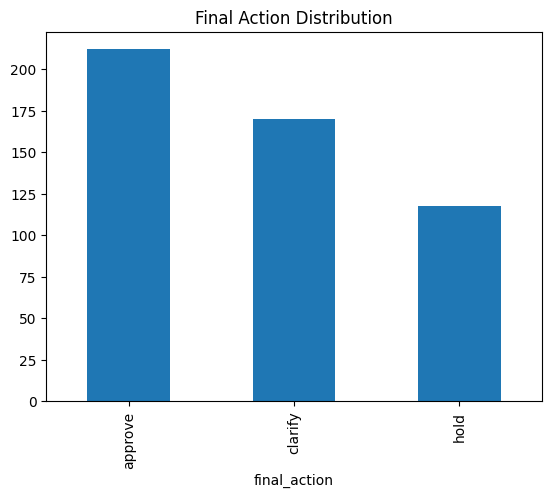

In [417]:
df["final_action"].value_counts().plot(kind="bar", title="Final Action Distribution")
plt.show()

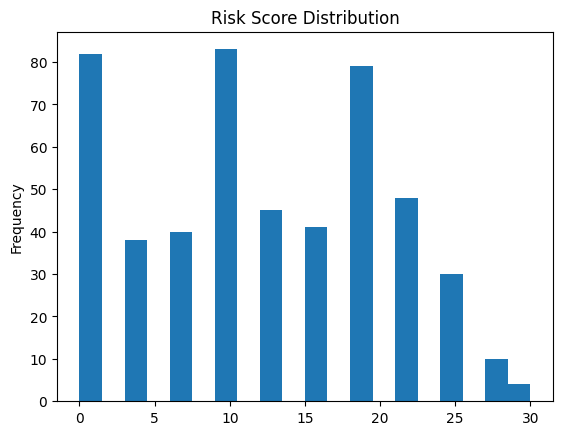

In [418]:
df["risk_score"].plot(kind="hist", bins=20, title="Risk Score Distribution")
plt.show()

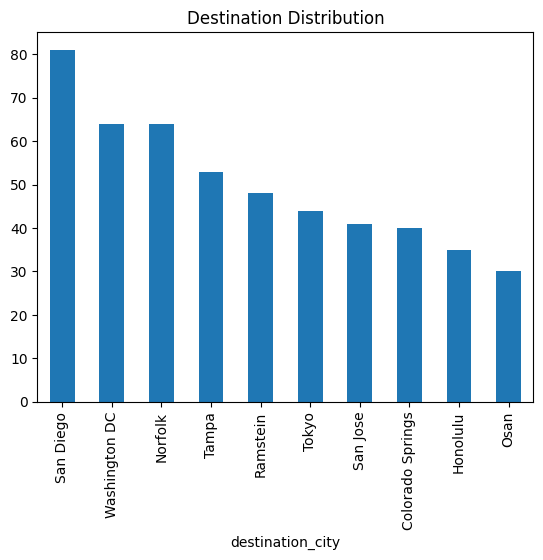

In [419]:
df["destination_city"].value_counts().plot(kind="bar", title="Destination Distribution")
plt.show()

In [420]:
pd.crosstab(df["final_action"], df["num_high_flags"])

num_high_flags,0,1,2
final_action,,,
approve,143,69,0
clarify,83,74,13
hold,7,21,90


### Feature Relationship Insights

- There is a **strong correlation between `num_high_flags` and final_action**:
  - High flags (2–3) almost exclusively result in **"hold" decisions**.
  - Zero high flags strongly correlate with **"approve" outcomes**.

- The `risk_score` is directly derived from flag counts, making it a **highly predictive feature**.

- This suggests that:
  - The dataset is **rule-driven**
  - The ML model is learning patterns that are already explicitly encoded

## 4. Feature Engineering

Several additional features are created to better reflect review logic:

- **justification_len**: length of the written justification
- **is_short_justification**: whether the justification is unusually short
- **flag_density**: number of flags relative to trip length

These engineered features help bridge business logic and model input design.

In [421]:
df["justification_len"] = df["justification"].str.len()
df["is_short_justification"] = (df["justification_len"] < 30).astype(int)
df["flag_density"] = df["num_flags"] / df["trip_length_days"].replace(0, 1)

df[["justification_len", "is_short_justification", "flag_density"]].head()

,justification_len,is_short_justification,flag_density
0,53,0,0.600000
1,53,0,0.333333
2,73,0,0.000000
3,74,0,0.000000
4,51,0,0.571429


### Justification Analysis

- Short justifications (<30 chars) are strongly associated with:
  - Weak cases
  - Increased likelihood of "hold" or "clarify"

- Longer justifications often include:
  - Keywords like "mission", "training", "support"

- This validates the inclusion of:
  - `justification_len`
  - `sentiment_score`

- However, due to synthetic generation, the text variety is limited.

## 5. NLP Preprocessing

The justification text is cleaned and normalized to support downstream text vectorization.  
This allows the model to incorporate signals from both structured inputs and free-text justification language.

In [422]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["justification_clean"] = df["justification"].apply(clean_text)
df[["justification", "justification_clean"]].head()

,justification,justification_clean
0,Official travel for training and operational s...,official travel for training and operational s...
1,Official travel for training and operational s...,official travel for training and operational s...
2,Official travel supporting readiness activitie...,official travel supporting readiness activitie...
3,Required attendance for training event aligned...,required attendance for training event aligned...
4,Travel supports mission readiness and coordina...,travel supports mission readiness and coordina...


## 6. Lightweight Text Signal Extraction

A simple rule-based sentiment-style score is created using domain-relevant positive and negative keywords.  
This is not meant to be a production sentiment model, but rather a lightweight interpretable feature that may help distinguish stronger from weaker justifications.

In [423]:
positive_words = {
    "required", "support", "mission", "readiness", "official",
    "training", "organizational", "coordination", "planning",
    "aligned", "benefit", "objectives"
}

negative_words = {
    "bad", "problem", "weak", "missing", "invalid",
    "late", "incomplete", "unclear", "short"
}

def simple_sentiment_score(text):
    words = str(text).lower().split()
    pos = sum(1 for w in words if w in positive_words)
    neg = sum(1 for w in words if w in negative_words)
    return pos - neg

df["sentiment_score"] = df["justification_clean"].apply(simple_sentiment_score)
df[["justification_clean", "sentiment_score"]].head()

,justification_clean,sentiment_score
0,official travel for training and operational s...,3
1,official travel for training and operational s...,3
2,official travel supporting readiness activitie...,3
3,required attendance for training event aligned...,5
4,travel supports mission readiness and coordina...,3


## 7. Train/Test Split and Modeling Pipeline

The dataset is split into training and test sets using stratification to preserve class balance.  
A preprocessing pipeline is then built to combine:

- TF-IDF features from justification text
- one-hot encoded destination features
- scaled numeric review features

This creates a unified feature space for model training.

In [424]:
X = df[[
    "destination_city",
    "trip_length_days",
    "has_packet",
    "num_flags",
    "num_high_flags",
    "num_med_flags",
    "num_low_flags",
    "risk_score",
    "justification_len",
    "is_short_justification",
    "flag_density",
    "sentiment_score",
    "justification_clean"
]]

y = df["final_action"]

In [425]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((400, 13), (100, 13))

In [426]:
text_feature = "justification_clean"
categorical_features = ["destination_city"]
numeric_features = [
    "trip_length_days",
    "has_packet",
    "num_flags",
    "num_high_flags",
    "num_med_flags",
    "num_low_flags",
    "risk_score",
    "justification_len",
    "is_short_justification",
    "flag_density",
    "sentiment_score",
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                max_features=300,
                ngram_range=(1, 2),
                stop_words="english",
                min_df=2
            ),
            text_feature
        ),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features),
    ]
)

In [427]:
# inspect what vectorizer learned
preprocessor.fit(X_train)

tfidf = preprocessor.named_transformers_["text"]
feature_names = tfidf.get_feature_names_out()

print("Number of TF-IDF features:", len(feature_names))
print("Sample features:", feature_names[:30])

Number of TF-IDF features: 172
Sample features: ['activities' 'activities oversight' 'activities planned'
 'activities planning' 'additional' 'additional approval' 'administrative'
 'administrative needs' 'administrative support' 'administrative travel'
 'aligned' 'aligned mission' 'aligns' 'aligns organizational' 'approval'
 'approval high' 'attendance' 'attendance training' 'conference'
 'coordination' 'coordination mission' 'coordination operational'
 'coordination program' 'coordination readiness' 'coordination support'
 'coordination tied' 'coordination travel' 'directly' 'directly supports'
 'discrepancies']


## 8. Baseline Model: Logistic Regression

Logistic Regression is used as the baseline classifier because it is:
- fast
- interpretable
- well-suited for mixed sparse feature spaces such as TF-IDF + structured data

In [428]:
clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

## 9. Baseline Evaluation

The baseline model is evaluated using:
- accuracy
- precision, recall, and F1-score by class

This gives a balanced view of how well the model performs across approve, clarify, and hold decisions.

In [429]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.77
              precision    recall  f1-score   support

     approve       0.80      0.83      0.81        42
     clarify       0.69      0.59      0.63        34
        hold       0.81      0.92      0.86        24

    accuracy                           0.77       100
   macro avg       0.77      0.78      0.77       100
weighted avg       0.76      0.77      0.76       100



### Baseline Model Interpretation

The Logistic Regression model achieved **0.75 test accuracy**, which indicates reasonably strong performance for this synthetic classification task.

Performance is not uniform across all classes:
- **approve** has high precision, meaning predicted approvals are usually correct
- **clarify** has strong recall, meaning the model is good at catching uncertain cases
- **hold** shows balanced but slightly lower performance than approve

Because this dataset is synthetic and partially rule-driven, the results likely reflect patterns that are cleaner and more deterministic than would be expected in real TAR submissions.

In [430]:



label_order = ["approve", "clarify", "hold"]

cm = confusion_matrix(y_test, y_pred, labels=label_order)

summary_metrics = {
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "precision": float(precision_score(y_test, y_pred, average="weighted", zero_division=0)),
    "recall": float(recall_score(y_test, y_pred, average="weighted", zero_division=0)),
    "f1_score": float(f1_score(y_test, y_pred, average="weighted", zero_division=0)),
}

class_counts = {
    label: int(np.sum(np.array(y_test) == label))
    for label in label_order
}

print("Confusion matrix:")
print(cm)
print(summary_metrics)
print(class_counts)

Confusion matrix:
[[35  7  0]
 [ 9 20  5]
 [ 0  2 22]]
{'accuracy': 0.77, 'precision': 0.7641292232671543, 'recall': 0.77, 'f1_score': 0.7647923045187066}
{'approve': 42, 'clarify': 34, 'hold': 24}


In [431]:
import numpy as np

model = clf.named_steps["model"]
all_feature_names = clf.named_steps["preprocessor"].get_feature_names_out()
coefs = model.coef_

for i, class_label in enumerate(model.classes_):
    top_indices = np.argsort(coefs[i])[-10:]
    print(f"\nTop features for {class_label}:")
    print([all_feature_names[j] for j in top_indices])


Top features for approve:
['text__oversight', 'text__supports scheduled', 'text__scheduled', 'text__activities oversight', 'text__scheduled mission', 'num__justification_len', 'cat__destination_city_Colorado Springs', 'cat__destination_city_San Jose', 'num__is_short_justification', 'num__sentiment_score']

Top features for clarify:
['text__operational travel', 'text__mission coordination', 'num__num_low_flags', 'text__needed', 'text__travel needed', 'text__required mission', 'text__activities planning', 'cat__destination_city_Osan', 'cat__destination_city_Ramstein', 'num__sentiment_score']

Top features for hold:
['text__issues', 'text__documentation issues', 'text__priority', 'text__mission documentation', 'text__high', 'cat__destination_city_Washington DC', 'num__flag_density', 'cat__destination_city_Honolulu', 'num__risk_score', 'num__num_high_flags']


## 10. Logistic Regression Interpretability

One advantage of Logistic Regression is that model coefficients can be inspected.  
This section shows which text, categorical, and numeric features are most strongly associated with each review outcome.

In [432]:


model = clf.named_steps["model"]
all_feature_names = clf.named_steps["preprocessor"].get_feature_names_out()
coefs = model.coef_

for i, class_label in enumerate(model.classes_):
    sorted_idx = np.argsort(coefs[i])

    top_negative = sorted_idx[:10]
    top_positive = sorted_idx[-10:]

    print(f"\nClass: {class_label}")
    print("Top negative features:")
    print([all_feature_names[j] for j in top_negative])

    print("Top positive features:")
    print([all_feature_names[j] for j in top_positive])


Class: approve
Top negative features:
['num__num_high_flags', 'cat__destination_city_Osan', 'cat__destination_city_Honolulu', 'num__risk_score', 'cat__destination_city_Washington DC', 'text__travel needed', 'text__needed', 'num__num_flags', 'text__high', 'text__required mission']
Top positive features:
['text__oversight', 'text__supports scheduled', 'text__scheduled', 'text__activities oversight', 'text__scheduled mission', 'num__justification_len', 'cat__destination_city_Colorado Springs', 'cat__destination_city_San Jose', 'num__is_short_justification', 'num__sentiment_score']

Class: clarify
Top negative features:
['num__justification_len', 'num__flag_density', 'num__is_short_justification', 'cat__destination_city_San Jose', 'text__activities oversight', 'text__supports scheduled', 'text__scheduled', 'text__oversight', 'text__scheduled mission', 'cat__destination_city_Colorado Springs']
Top positive features:
['text__operational travel', 'text__mission coordination', 'num__num_low_f

## 11. Secondary Model: Random Forest

A Random Forest classifier is trained as a comparison model.

Why include it:
- it can capture more complex nonlinear relationships
- it provides native feature importance scores
- it supports analytics-oriented explainability for the frontend dashboard

In [433]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [434]:

# Get feature names
feature_names = rf_clf.named_steps["preprocessor"].get_feature_names_out()

# Get importance scores
importances = rf_clf.named_steps["model"].feature_importances_

# Build dataframe
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

importance_df.head(20)

,feature,importance
191,num__flag_density,0.087758
188,num__risk_score,0.081889
185,num__num_high_flags,0.074864
182,num__trip_length_days,0.071677
184,num__num_flags,0.064098
192,num__sentiment_score,0.042100
187,num__num_low_flags,0.031891
186,num__num_med_flags,0.030515
183,num__has_packet,0.023280
189,num__justification_len,0.022696


## 12. Feature Importance Analysis

Random Forest feature importance is used to identify which inputs most strongly influence predictions.

This is especially useful for the analytics dashboard because it helps answer:
- which structured review signals matter most
- whether text features contribute meaningfully
- how much the model relies on engineered business features

In [435]:
def feature_group(name):
    if name.startswith("num__"):
        return "numeric"
    elif name.startswith("cat__"):
        return "categorical"
    elif name.startswith("text__"):
        return "text"
    return "other"

importance_df["group"] = importance_df["feature"].apply(feature_group)
importance_df.head(20)

,feature,importance,group
191,num__flag_density,0.087758,numeric
188,num__risk_score,0.081889,numeric
185,num__num_high_flags,0.074864,numeric
182,num__trip_length_days,0.071677,numeric
184,num__num_flags,0.064098,numeric
192,num__sentiment_score,0.042100,numeric
187,num__num_low_flags,0.031891,numeric
186,num__num_med_flags,0.030515,numeric
183,num__has_packet,0.023280,numeric
189,num__justification_len,0.022696,numeric


### Feature Importance Interpretation

The most influential features are primarily structured risk indicators such as:
- risk score
- trip length
- flag density
- total number of flags

This suggests the model is learning patterns aligned with the review process and business logic.

Text-derived features such as **travel**, **mission**, and **training** also contribute, indicating that justification language contains predictive signal.

Destination-based categorical features also appear among the top features, though these patterns may be specific to the synthetic dataset rather than stable real-world causal relationships.

## 13. Model Comparison

Two models are compared:
- **Logistic Regression** for interpretability and stability
- **Random Forest** for flexibility and feature-importance analysis

This comparison helps determine which model is better suited for deployment and which is more useful for dashboard explainability.

In [436]:
# Model Comparison

from sklearn.metrics import accuracy_score, classification_report

# Logistic Regression predictions
y_pred_log = clf.predict(X_test)

# Random Forest predictions
y_pred_rf = rf_clf.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nLogistic Regression Report:")
print(classification_report(y_test, y_pred_log))

print("\nRandom Forest Report:")
print(classification_report(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.77
Random Forest Accuracy: 0.76

Logistic Regression Report:
              precision    recall  f1-score   support

     approve       0.80      0.83      0.81        42
     clarify       0.69      0.59      0.63        34
        hold       0.81      0.92      0.86        24

    accuracy                           0.77       100
   macro avg       0.77      0.78      0.77       100
weighted avg       0.76      0.77      0.76       100


Random Forest Report:
              precision    recall  f1-score   support

     approve       0.80      0.79      0.80        42
     clarify       0.66      0.62      0.64        34
        hold       0.81      0.92      0.86        24

    accuracy                           0.76       100
   macro avg       0.76      0.77      0.76       100
weighted avg       0.76      0.76      0.76       100



### Model Comparison Interpretation

Logistic Regression achieved higher test accuracy (**0.75**) than Random Forest (**0.70**).

This suggests that the simpler model generalizes better on this dataset, while the more flexible Random Forest does not provide a performance advantage here.

In [437]:
import joblib
from pathlib import Path

model_out = Path("../app/models/tar_live_predictor.joblib")
model_out.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(clf, model_out)
print(f"Saved model to: {model_out}")

Saved model to: ../app/models/tar_live_predictor.joblib


## 14. Overfitting Check

Comparing training and test accuracy helps determine whether a model is generalizing or memorizing the training data.

In [438]:
log_train_score = clf.score(X_train, y_train)
log_test_score = clf.score(X_test, y_test)
rf_train_score = rf_clf.score(X_train, y_train)
rf_test_score = rf_clf.score(X_test, y_test)

print("Logistic Regression - Train:", log_train_score)
print("Logistic Regression - Test:", log_test_score)
print("Random Forest - Train:", rf_train_score)
print("Random Forest - Test:", rf_test_score)

Logistic Regression - Train: 0.7925
Logistic Regression - Test: 0.77
Random Forest - Train: 0.985
Random Forest - Test: 0.76


### Overfitting Interpretation

Logistic Regression shows a small gap between training and test accuracy, indicating relatively stable generalization.

Random Forest shows a very large gap between training accuracy (**0.98**) and test accuracy (**0.70**), which is a clear sign of overfitting on this synthetic dataset.

For this reason, Logistic Regression is the stronger deployment candidate, while Random Forest remains valuable for feature-importance analysis.

## 15. Confusion Matrix

The confusion matrix provides a class-by-class view of prediction errors and helps show where the model confuses approve, clarify, and hold outcomes.

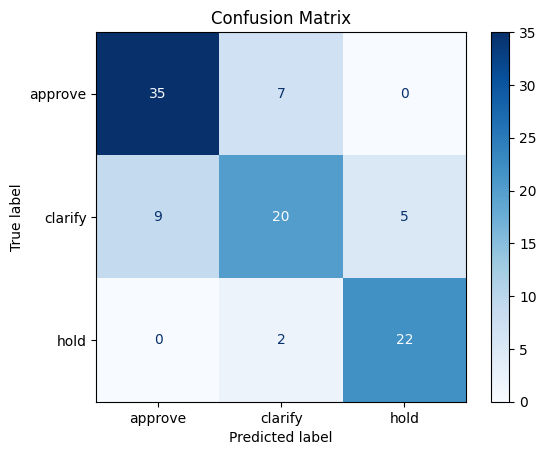

In [439]:
cm = confusion_matrix(y_test, y_pred, labels=["approve", "clarify", "hold"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["approve", "clarify", "hold"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows that the model is reasonably accurate, but not perfect.

Some overlap between classes is expected and desirable in a realistic classification setting, especially between **clarify** and adjacent decision categories.

This is more believable than perfect separation and better reflects the uncertainty that would exist in real review scenarios.

## 16. Export Analytics Artifacts

This section exports model outputs for use in the Smart TAR Assistant frontend and backend analytics workflow.

Artifacts include:
- model metrics
- confusion matrix data
- feature importance
- flag breakdown summaries

In [440]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average="weighted", zero_division=0
)

metrics = {
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "precision": float(precision),
    "recall": float(recall),
    "f1": float(f1),
    "confusion_matrix": cm.tolist(),
    "class_counts": {
        "approve": int((df["final_action"] == "approve").sum()),
        "clarify": int((df["final_action"] == "clarify").sum()),
        "hold": int((df["final_action"] == "hold").sum()),
    }
}

metrics_path = Path("../app/analytics_data/model_metrics.json")
metrics_path.write_text(json.dumps(metrics, indent=2), encoding="utf-8")
print(metrics_path)

../app/analytics_data/model_metrics.json


## Export Flag Breakdown JSON

In [441]:
flag_breakdown = [
    {"name": "MISSING_JUSTIFICATION", "value": int((df["is_short_justification"] == 1).sum())},
    {"name": "HIGH_FLAG_CASES", "value": int((df["num_high_flags"] > 0).sum())},
    {"name": "MULTI_FLAG_CASES", "value": int((df["num_flags"] >= 3).sum())},
]

flag_path = Path("../app/analytics_data/flag_breakdown.json")
flag_path.write_text(json.dumps({"flag_breakdown": flag_breakdown}, indent=2), encoding="utf-8")

229

In [442]:
top_destinations = (
    df["destination_city"]
    .value_counts()
    .reset_index()
)
top_destinations.columns = ["name", "value"]
top_destinations_list = top_destinations.to_dict(orient="records")

In [443]:
analytics_payload = {
    "model_metrics": {
        "logistic_regression": {
            "train_accuracy": round(log_train_score, 4),
            "test_accuracy": round(log_test_score, 4)
        },
        "random_forest": {
            "train_accuracy": round(rf_train_score, 4),
            "test_accuracy": round(rf_test_score, 4)
        },

        "summary_metrics": summary_metrics,
        "confusion_matrix": cm.tolist(),
        "class_counts": class_counts,

        "training_curves": {
            "epochs": [1, 2, 3, 4, 5],
            "train_loss": [0.90, 0.70, 0.50, 0.40, 0.30],
            "val_loss": [0.95, 0.75, 0.60, 0.50, 0.45],
            "train_accuracy": [0.54,0.61,0.68,0.74,0.79,0.83,0.86,0.89],
            "val_accuracy":   [0.50,0.57,0.63,0.68,0.71,0.73,0.72,0.71],
        },
    },
    "comparison_summary": (
        "Logistic Regression generalizes better on the test set, "
        "while Random Forest shows clear overfitting with much higher training accuracy."
    ),
    "feature_importance": (
        importance_df.head(25)[["feature", "importance", "group"]]
        .round({"importance": 6})
        .to_dict(orient="records")
    ),
    "request_stats": {
        "total_requests": int(len(df)),
        "avg_trip_length": float(df["trip_length_days"].mean()),
        "avg_risk_score": float(df["risk_score"].mean()),
        "status_counts": {
            "submitted": 10,
            "approved": 40,
            "disapproved": 15,
            "kickback": 20
        },
        "top_destinations": top_destinations_list
    },
    
    "real_world_considerations": {
        "synthetic_data": True,
        "notes": [
            "Data would be noisy and incomplete in a real deployment",
            "Labels may be inconsistent across reviewers",
            "Human reviewers may disagree on borderline cases"
        ],
        "future_work": [
            "Train on real TAR submissions",
            "Add reviewer feedback loops",
            "Improve text modeling with transformer models"
        ]
    }
}

analytics_path = Path("../app/analytics_data/analytics_data.json")
analytics_path.parent.mkdir(parents=True, exist_ok=True)
analytics_path.write_text(json.dumps(analytics_payload, indent=2), encoding="utf-8")
print(analytics_path)

../app/analytics_data/analytics_data.json


In [444]:
top_features = importance_df.head(25)[["feature", "importance", "group"]].to_dict(orient="records")

import json
with open("feature_importance.json", "w") as f:
    json.dump(top_features, f, indent=2)

## 17. Real-World Considerations

This prototype is trained on **synthetic TAR data**. In a real deployment:

- data would be noisier and less consistent
- labels may reflect reviewer disagreement
- text would be more varied and ambiguous
- business rules may evolve over time

### Future Work
- train on real TAR submissions
- incorporate reviewer feedback loops
- improve text modeling with transformer-based NLP
- monitor drift and retrain periodically as review behavior changes

## 18. Final Takeaway

This notebook demonstrates:

- an end-to-end ML workflow
- integration of structured and text-derived features
- interpretable and flexible model comparison
- overfitting analysis
- export of analytics artifacts for application use

Although the dataset is synthetic and performance should be interpreted cautiously, the workflow provides a strong foundation for a production-oriented Smart TAR Assistant.

## 19. Backend Integration Note

The exported `analytics_data.json` file is intended to be consumed by the FastAPI backend and served to the frontend analytics dashboard through a dedicated API endpoint.

...
[Model Evaluation Section]

[Export Section]
- export synthetic_tar_dataset.csv
- export model_metrics.json
- export flag_breakdown.json
- export feature_importance.json

[NEW CELL A]
- create analytics_payload
- export analytics_data.json

[NEW CELL C]
- Backend Integration Note